**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 10 — Evaluation & Ablation Study

Loads all trained checkpoints and produces:
- Full metric table (accuracy, F1, AUROC, precision, recall)
- ROC curves
- Confusion matrices
- Ablation comparison bar chart
- Optimal threshold search
- Failure case sampling

In [1]:
import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
 )
from transformers import CLIPModel, CLIPProcessor

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")

def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)

def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)

def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])

def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    for default_sub in (
        "meta-hateful-meme-detection/data",
        "datasets/muddybuddy/meta-hateful-meme-detection/data",
    ):
        default_candidate = kaggle_input / default_sub
        if _looks_like_dataset_root(default_candidate):
            return default_candidate, f"default:{default_candidate}"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"

def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None

DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
if DEV_PATH is None:
    raise FileNotFoundError(f"Expected dev split under {DATA_DIR}")

LOCAL_OUTPUT_DIR = Path.cwd() / "outputs"
OPT_OUTPUT_DIR = LOCAL_OUTPUT_DIR / "training_optimization"
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else LOCAL_OUTPUT_DIR
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CFG = {
    "clip_model": "openai/clip-vit-base-patch32",
    "batch_size": 64,
    "embed_dim": 512,
    "proj_dim": 512,
    "num_heads": 4,
    "dropout": 0.3,
    "max_text_len": 77,
}
CLIP_MODEL_SOURCE = CFG["clip_model"]

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

def clean_text(text):
    if not isinstance(text, str):
        return "[no text]"
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip() or "[no text]"

dev_df = load_jsonl(DEV_PATH)
dev_df["clean_text"] = dev_df["text"].apply(clean_text)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Opt output dir : {OPT_OUTPUT_DIR}")
print(f"Device         : {DEVICE}")
print(f"Dev size       : {len(dev_df):,}")

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using source   : default:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Opt output dir : /kaggle/working/outputs/training_optimization
Device         : cuda
Dev size       : 500


In [2]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

In [ ]:
# ── Inline model definitions (matched to notebooks 08/09/09b/09c) ────
def _ensure_tensor(out):
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, "last_hidden_state"):
        return out.last_hidden_state[:, 0]
    return out[0]

class MemeDataset(Dataset):
    def __init__(self, df, data_dir, processor):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(resolve_image_path(self.data_dir, row["img"])).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), 128)
        text = str(row.get("clean_text", row["text"]))
        enc = self.processor(
            text=[text],
            images=img,
            return_tensors="pt",
            padding="max_length",
            max_length=CFG["max_text_len"],
            truncation=True,
        )
        return {
            "pixel_values": enc["pixel_values"].squeeze(0),
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
        }

class CLIPEncoder(nn.Module):
    def __init__(self, model_name=None):
        super().__init__()
        model_name = model_name or CLIP_MODEL_SOURCE
        self.clip = CLIPModel.from_pretrained(model_name, local_files_only=Path(str(model_name)).exists())
        for p in self.clip.parameters():
            p.requires_grad_(False)

    def forward(self, pixel_values, input_ids, attention_mask):
        image_features = _ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        text_features = _ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
        i = F.normalize(image_features, dim=-1)
        t = F.normalize(text_features, dim=-1)
        return i, t

class CrossAttentionFusion(nn.Module):
    def __init__(self, d=512, heads=4, drop=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ni = nn.LayerNorm(d)
        self.nt = nn.LayerNorm(d)

    def forward(self, i, t):
        is_ = i.unsqueeze(1)
        ts = t.unsqueeze(1)
        ic, ia = self.i2t(is_, ts, ts)
        tc, ta = self.t2i(ts, is_, is_)
        return torch.cat([self.ni(i + ic.squeeze(1)), self.nt(t + tc.squeeze(1))], -1), ia, ta

class ClassificationHead(nn.Module):
    def __init__(self, d=1024, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

class HatefulMemeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder()
        self.fusion = CrossAttentionFusion(CFG["embed_dim"], CFG["num_heads"] )
        self.head = ClassificationHead(CFG["embed_dim"] * 2, CFG["dropout"] )

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta

# ── ViT-L/14 variant from notebook 09c ──────────────────────────────
CFG_L14 = {
    "clip_model": "openai/clip-vit-large-patch14",
    "embed_dim": 768,
    "num_heads": 8,
    "dropout": 0.3,
    "max_text_len": 77,
}
CLIP_L14_SOURCE = CFG_L14["clip_model"]   # overwritten in cell 6 after caching

class ClassificationHeadL14(nn.Module):
    def __init__(self, d=1536, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 512), nn.GELU(), nn.Dropout(drop),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.net(x)

class HatefulMemeClassifierL14(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder(model_name=CLIP_L14_SOURCE)
        self.fusion = CrossAttentionFusion(CFG_L14["embed_dim"], CFG_L14["num_heads"])
        self.head = ClassificationHeadL14(CFG_L14["embed_dim"] * 2, CFG_L14["dropout"])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta

class ImageOnlyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CLIP_MODEL_SOURCE, local_files_only=Path(str(CLIP_MODEL_SOURCE)).exists())
        for p in self.clip.parameters():
            p.requires_grad_(False)
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 2),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        f = _ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        f = F.normalize(f, dim=-1)
        return self.head(f), None, None

class TextOnlyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CLIP_MODEL_SOURCE, local_files_only=Path(str(CLIP_MODEL_SOURCE)).exists())
        for p in self.clip.parameters():
            p.requires_grad_(False)
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 2),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        f = _ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
        f = F.normalize(f, dim=-1)
        return self.head(f), None, None

class LateFusionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CLIP_MODEL_SOURCE, local_files_only=Path(str(CLIP_MODEL_SOURCE)).exists())
        for p in self.clip.parameters():
            p.requires_grad_(False)
        self.head = nn.Sequential(
            nn.Linear(1024, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.GELU(), nn.Linear(128, 2),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        i = _ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        t = _ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
        i = F.normalize(i, dim=-1)
        t = F.normalize(t, dim=-1)
        return self.head(torch.cat([i, t], -1)), None, None

class TokenLevelCrossAttentionModel(nn.Module):
    def __init__(self, model_name=None, proj_dim=CFG["proj_dim"], heads=CFG["num_heads"], dropout=0.2):
        super().__init__()
        model_name = model_name or CLIP_MODEL_SOURCE
        self.clip = CLIPModel.from_pretrained(model_name, local_files_only=Path(str(model_name)).exists())
        clip_vision_dim = self.clip.vision_model.config.hidden_size
        clip_text_dim = self.clip.text_model.config.hidden_size
        clip_proj_dim = self.clip.visual_projection.out_features
        self.vision_proj = nn.Linear(clip_vision_dim, proj_dim)
        self.text_proj = nn.Linear(clip_text_dim, proj_dim)
        self.text_to_image = nn.MultiheadAttention(proj_dim, heads, dropout=dropout, batch_first=True)
        self.image_to_text = nn.MultiheadAttention(proj_dim, heads, dropout=dropout, batch_first=True)
        self.text_norm = nn.LayerNorm(proj_dim)
        self.image_norm = nn.LayerNorm(proj_dim)
        self.dropout_layer = nn.Dropout(dropout)
        classifier_in = proj_dim * 2 + clip_proj_dim * 2 + 1
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def masked_mean(self, x, mask):
        mask = mask.unsqueeze(-1).float()
        return (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

    def forward(self, pixel_values, input_ids, attention_mask):
        vision_out = self.clip.vision_model(pixel_values=pixel_values)
        text_out = self.clip.text_model(input_ids=input_ids, attention_mask=attention_mask)
        vision_tokens = self.vision_proj(vision_out.last_hidden_state)
        text_tokens = self.text_proj(text_out.last_hidden_state)
        key_padding_mask = attention_mask == 0
        text_ctx, text_attn = self.text_to_image(text_tokens, vision_tokens, vision_tokens)
        image_ctx, image_attn = self.image_to_text(
            vision_tokens, text_tokens, text_tokens, key_padding_mask=key_padding_mask
        )
        text_tokens = self.text_norm(text_tokens + self.dropout_layer(text_ctx))
        image_tokens = self.image_norm(vision_tokens + self.dropout_layer(image_ctx))
        pooled_text = self.masked_mean(text_tokens, attention_mask)
        pooled_image = image_tokens.mean(dim=1)
        global_image = F.normalize(self.clip.visual_projection(vision_out.pooler_output), dim=-1)
        global_text = F.normalize(self.clip.text_projection(text_out.pooler_output), dim=-1)
        cosine = F.cosine_similarity(global_image, global_text).unsqueeze(-1)
        fused = torch.cat([pooled_image, pooled_text, global_image, global_text, cosine], dim=-1)
        return self.classifier(fused), text_attn, image_attn

print("Model classes loaded.")

Model classes loaded.


In [ ]:
# ── Load checkpoints and run inference ───────────────────────────────
import time
import shutil

def _is_valid_clip_cache(cache_dir, expected_proj_dim):
    """Check cache has config.json + tokenizer_config.json AND correct projection_dim."""
    cfg_path = Path(cache_dir) / "config.json"
    tok_path = Path(cache_dir) / "tokenizer_config.json"
    if not cfg_path.exists() or not tok_path.exists():
        return False
    try:
        with open(cfg_path, encoding="utf-8") as f:
            cfg_data = json.load(f)
        proj_dim = cfg_data.get("projection_dim", -1)
        if proj_dim != expected_proj_dim:
            print(f"WARNING: Cache at {cache_dir} has projection_dim={proj_dim}, expected {expected_proj_dim}. Will re-download.", flush=True)
            return False
        return True
    except Exception:
        return False

# ── Cache ViT-B/32 ──────────────────────────────────────────────────
clip_cache_dir = OUTPUT_DIR / "hf_clip_cache" / "clip-vit-base-patch32"
clip_cache_dir.mkdir(parents=True, exist_ok=True)

if _is_valid_clip_cache(clip_cache_dir, CFG["embed_dim"]):
    CLIP_MODEL_SOURCE = str(clip_cache_dir)
    print(f"Using cached CLIP B/32 from {CLIP_MODEL_SOURCE}", flush=True)
else:
    print("Downloading CLIP B/32 model + processor to local cache...", flush=True)
    if clip_cache_dir.exists():
        shutil.rmtree(str(clip_cache_dir))
        clip_cache_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.perf_counter()
    base_clip = CLIPModel.from_pretrained(CFG["clip_model"])
    base_clip.save_pretrained(str(clip_cache_dir))
    del base_clip
    print(f"  Model cached in {time.perf_counter() - t0:.1f}s", flush=True)
    t1 = time.perf_counter()
    base_proc = CLIPProcessor.from_pretrained(CFG["clip_model"])
    base_proc.save_pretrained(str(clip_cache_dir))
    del base_proc
    print(f"  Processor cached in {time.perf_counter() - t1:.1f}s", flush=True)
    torch.cuda.empty_cache()
    CLIP_MODEL_SOURCE = str(clip_cache_dir)
    print(f"CLIP B/32 cached to {CLIP_MODEL_SOURCE}", flush=True)

# ── Cache ViT-L/14 (only if checkpoint exists) ──────────────────────
clip_l14_cache_dir = OUTPUT_DIR / "hf_clip_cache" / "clip-vit-large-patch14"
clip_l14_cache_dir.mkdir(parents=True, exist_ok=True)

def _find_vitl14_checkpoint():
    """Check if vitl14 checkpoint exists before downloading the large model."""
    for fn in ("vitl14_unfrozen_best.pt", "vitl14_frozen_best.pt"):
        search_dirs = [
            OUTPUT_DIR,
            LOCAL_OUTPUT_DIR / "training_vitl14",
            OPT_OUTPUT_DIR,
            LOCAL_OUTPUT_DIR,
        ]
        if ON_KAGGLE:
            search_dirs.append(Path("/kaggle/working"))
            if Path("/kaggle/input").is_dir():
                for d in sorted(Path("/kaggle/input").iterdir()):
                    if d.is_dir():
                        search_dirs.append(d)
        for d in search_dirs:
            if (d / fn).is_file():
                return True
        if ON_KAGGLE and Path("/kaggle/input").is_dir():
            if list(Path("/kaggle/input").rglob(fn)):
                return True
    return False

HAS_L14_CKPT = _find_vitl14_checkpoint()

if HAS_L14_CKPT:
    if _is_valid_clip_cache(clip_l14_cache_dir, CFG_L14["embed_dim"]):
        CLIP_L14_SOURCE = str(clip_l14_cache_dir)
        print(f"Using cached CLIP L/14 from {CLIP_L14_SOURCE}", flush=True)
    else:
        print("Downloading CLIP L/14 model + processor to local cache (large ~1.7 GB)...", flush=True)
        if clip_l14_cache_dir.exists():
            shutil.rmtree(str(clip_l14_cache_dir))
            clip_l14_cache_dir.mkdir(parents=True, exist_ok=True)
        t0 = time.perf_counter()
        l14_clip = CLIPModel.from_pretrained(CFG_L14["clip_model"])
        l14_clip.save_pretrained(str(clip_l14_cache_dir))
        del l14_clip
        print(f"  L/14 model cached in {time.perf_counter() - t0:.1f}s", flush=True)
        t1 = time.perf_counter()
        l14_proc = CLIPProcessor.from_pretrained(CFG_L14["clip_model"])
        l14_proc.save_pretrained(str(clip_l14_cache_dir))
        del l14_proc
        print(f"  L/14 processor cached in {time.perf_counter() - t1:.1f}s", flush=True)
        torch.cuda.empty_cache()
        CLIP_L14_SOURCE = str(clip_l14_cache_dir)
        print(f"CLIP L/14 cached to {CLIP_L14_SOURCE}", flush=True)
else:
    print("No ViT-L/14 checkpoint found — skipping L/14 CLIP download", flush=True)

# ── B/32 dataloader (used for most variants) ─────────────────────────
print("Creating B/32 processor & dataloader...", flush=True)
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_SOURCE, use_fast=False, local_files_only=True)
dev_ds = MemeDataset(dev_df, DATA_DIR, processor)
dev_loader = DataLoader(
    dev_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
print(f"B/32 dataloader ready — {len(dev_loader)} batches", flush=True)

# ── L/14 dataloader (only if checkpoint exists) ──────────────────────
dev_loader_l14 = None
if HAS_L14_CKPT:
    print("Creating L/14 processor & dataloader...", flush=True)
    processor_l14 = CLIPProcessor.from_pretrained(CLIP_L14_SOURCE, use_fast=False, local_files_only=True)
    dev_ds_l14 = MemeDataset(dev_df, DATA_DIR, processor_l14)
    dev_loader_l14 = DataLoader(
        dev_ds_l14,
        batch_size=32,  # smaller batch for larger model
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    print(f"L/14 dataloader ready — {len(dev_loader_l14)} batches", flush=True)

def find_checkpoint(filename):
    search_dirs = [
        OUTPUT_DIR,
        OPT_OUTPUT_DIR,
        LOCAL_OUTPUT_DIR / "baselines",
        LOCAL_OUTPUT_DIR / "training_vitl14",
        LOCAL_OUTPUT_DIR,
    ]
    if ON_KAGGLE:
        kaggle_input = Path("/kaggle/input")
        search_dirs.append(Path("/kaggle/working"))
        if kaggle_input.is_dir():
            for d in sorted(kaggle_input.iterdir()):
                if d.is_dir():
                    search_dirs.append(d)
    for d in search_dirs:
        candidate = d / filename
        if candidate.is_file():
            return candidate
    if ON_KAGGLE and Path("/kaggle/input").is_dir():
        matches = sorted(Path("/kaggle/input").rglob(filename))
        if matches:
            return matches[0]
    return None

VARIANTS = [
    ("cross_attention", HatefulMemeClassifier, "cross_attention_best.pt", dev_loader),
    ("cross_attention_phase2", HatefulMemeClassifier, "cross_attention_phase2_best.pt", dev_loader),
    ("cross_attention_vitl14", HatefulMemeClassifierL14, "vitl14_unfrozen_best.pt", dev_loader_l14),
    ("cross_attention_token_level", TokenLevelCrossAttentionModel, "cross_attention_token_level_best.pt", dev_loader),
    ("image_only", ImageOnlyClassifier, "image_only_best.pt", dev_loader),
    ("text_only", TextOnlyClassifier, "text_only_best.pt", dev_loader),
    ("late_fusion", LateFusionClassifier, "late_fusion_best.pt", dev_loader),
]

eval_results = {}

for name, ModelClass, ckpt_name, loader in VARIANTS:
    if loader is None:
        print(f"SKIP {name} — no dataloader (L/14 not cached)", flush=True)
        continue
    ckpt = find_checkpoint(ckpt_name)
    if ckpt is None:
        print(f"SKIP {name} — checkpoint '{ckpt_name}' not found", flush=True)
        continue

    total_batches = len(loader)
    model = None
    try:
        t0 = time.perf_counter()
        print(f"\n▸ {name}", flush=True)
        print(f"  checkpoint: {ckpt}", flush=True)
        print(f"  building model architecture...", flush=True)
        model = ModelClass()
        print(f"  architecture built ({time.perf_counter() - t0:.1f}s)", flush=True)

        t1 = time.perf_counter()
        print(f"  loading checkpoint weights...", flush=True)
        state = torch.load(ckpt, map_location="cpu", weights_only=False)
        model.load_state_dict(state)
        print(f"  weights loaded ({time.perf_counter() - t1:.1f}s)", flush=True)

        t2 = time.perf_counter()
        model = model.to(DEVICE)
        model.eval()
        print(f"  model on {DEVICE} ({time.perf_counter() - t2:.1f}s)", flush=True)

        all_probs, all_preds, all_labs = [], [], []
        infer_t0 = time.perf_counter()
        with torch.no_grad():
            for batch_idx, batch in enumerate(loader, start=1):
                pv = batch["pixel_values"].to(DEVICE, non_blocking=True)
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                logits, _, _ = model(pv, ids, mask)
                probs = torch.softmax(logits.float(), -1)[:, 1].cpu().numpy()
                preds = logits.argmax(-1).cpu().numpy()
                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labs.extend(batch["label"].numpy())
                if batch_idx == 1 or batch_idx == total_batches:
                    print(f"  batch {batch_idx}/{total_batches} ({time.perf_counter() - infer_t0:.1f}s)", flush=True)

        eval_results[name] = {
            "probs": np.array(all_probs),
            "preds": np.array(all_preds),
            "labels": np.array(all_labs),
        }
        print(f"  ✓ done — {len(all_labs)} samples, {time.perf_counter() - t0:.1f}s total", flush=True)
    except Exception as exc:
        print(f"  ✗ FAILED: {type(exc).__name__}: {exc}", flush=True)
    finally:
        if model is not None:
            del model
        torch.cuda.empty_cache()

print(f"\nLoaded {len(eval_results)}/{len(VARIANTS)} variants", flush=True)
if not eval_results:
    print("WARNING: No compatible checkpoints found.", flush=True)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  architecture built (0.5s)
  loading checkpoint weights...
  weights loaded (7.9s)
  model on cuda (0.2s)
  batch 1/8 (1.5s)
  batch 8/8 (12.9s)
  ✓ done — 500 samples, 21.5s total

▸ text_only
  checkpoint: /kaggle/input/notebooks/muddybuddy/08-training/text_only_best.pt
  building model architecture...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  architecture built (0.5s)
  loading checkpoint weights...
  weights loaded (4.0s)
  model on cuda (0.2s)
  batch 1/8 (1.4s)
  batch 8/8 (10.9s)
  ✓ done — 500 samples, 15.7s total

▸ late_fusion
  checkpoint: /kaggle/input/notebooks/muddybuddy/08-training/late_fusion_best.pt
  building model architecture...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  architecture built (0.8s)
  loading checkpoint weights...
  weights loaded (7.0s)
  model on cuda (0.2s)
  batch 1/8 (1.8s)
  batch 8/8 (13.8s)
  ✓ done — 500 samples, 21.8s total

Loaded 4/5 variants


In [5]:
# -- Metrics table ----------------------------------------------------
if not eval_results:
    print("SKIPPED: no checkpoints loaded, so metrics table was not generated.")
    metrics_df = pd.DataFrame()
else:
    rows = []
    for name, res in eval_results.items():
        labs, preds, probs = res["labels"], res["preds"], res["probs"]
        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(labs, preds),
            "Precision": precision_score(labs, preds, pos_label=1),
            "Recall": recall_score(labs, preds, pos_label=1),
            "F1 (Hateful)": f1_score(labs, preds, pos_label=1),
            "Macro F1": f1_score(labs, preds, average="macro"),
            "AUROC": roc_auc_score(labs, probs),
        })

    metrics_df = pd.DataFrame(rows)
    print("\nABLATION STUDY RESULTS")
    print("=" * 78)
    print(metrics_df.to_string(index=False, float_format="{:.4f}".format))
    metrics_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results.csv"), index=False)


ABLATION STUDY RESULTS
          Model  Accuracy  Precision  Recall  F1 (Hateful)  Macro F1  AUROC
cross_attention    0.6480     0.6242  0.7440        0.6788    0.6447 0.7017
     image_only    0.4980     0.4839  0.0600        0.1068    0.3788 0.4983
      text_only    0.5000     0.0000  0.0000        0.0000    0.3333 0.4558
    late_fusion    0.5000     0.0000  0.0000        0.0000    0.3333 0.5125


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


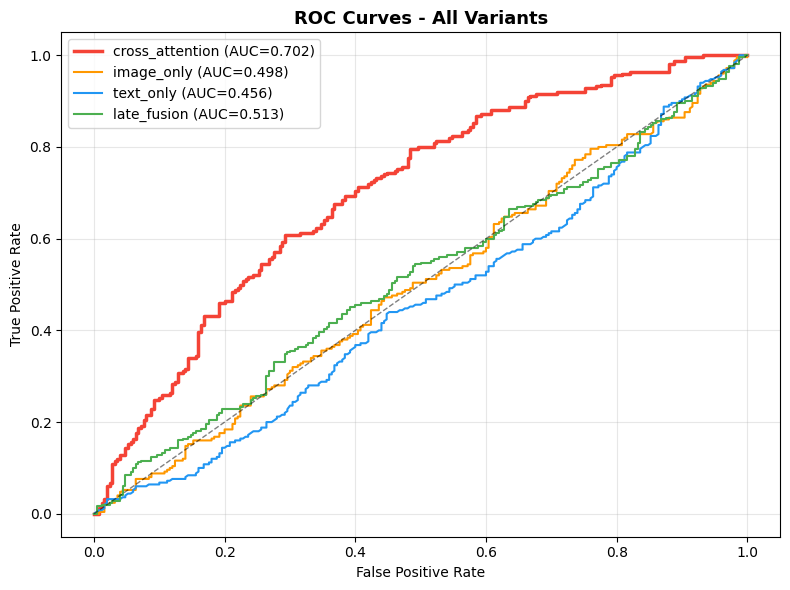

In [ ]:
# -- ROC curves -------------------------------------------------------
if not eval_results:
    print("SKIPPED: no checkpoints loaded, so ROC plot was not generated.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {
        "cross_attention": "#F44336",
        "cross_attention_phase2": "#E91E63",
        "cross_attention_vitl14": "#FF5722",
        "cross_attention_token_level": "#9C27B0",
        "image_only": "#FF9800",
        "text_only": "#2196F3",
        "late_fusion": "#4CAF50",
    }

    for name, res in eval_results.items():
        fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
        auc_val = auc(fpr, tpr)
        lw = 2.5 if "cross_attention" in name and "token" not in name else 1.5
        ax.plot(fpr, tpr, lw=lw, color=colors.get(name, "gray"),
                label=f"{name} (AUC={auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves - All Variants", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

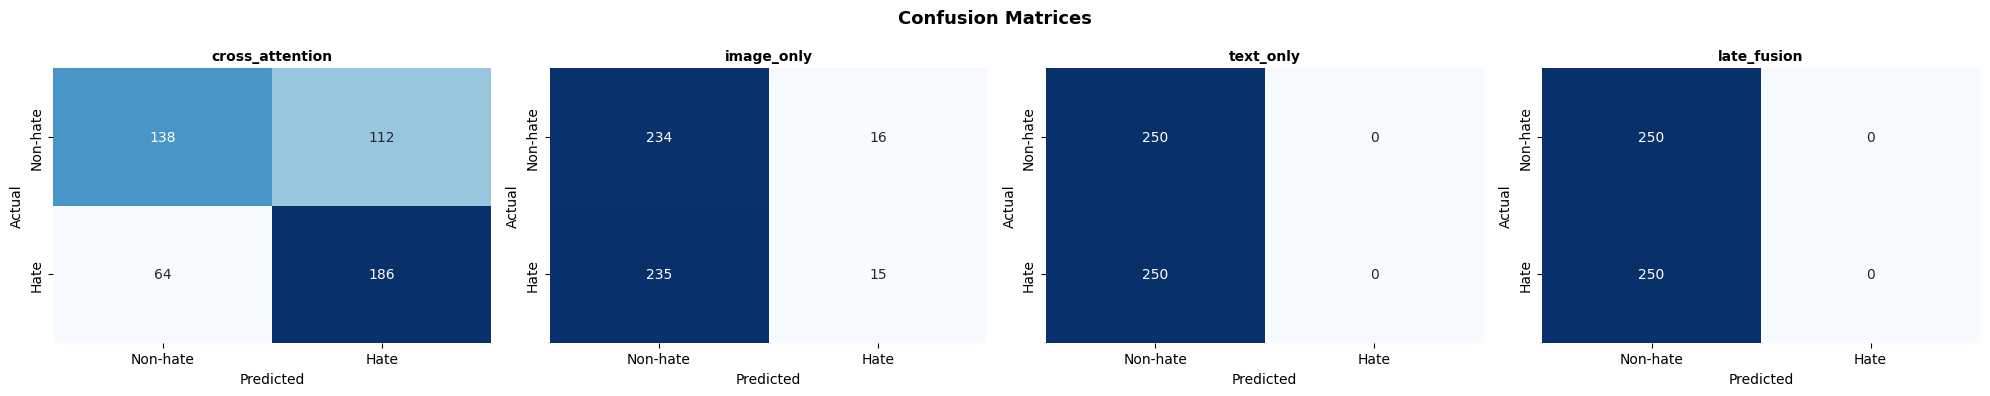

In [7]:
# -- Confusion matrices -----------------------------------------------
if not eval_results:
    print("SKIPPED: no checkpoints loaded, so confusion matrices were not generated.")
else:
    n_variants = len(eval_results)
    fig, axes = plt.subplots(1, n_variants, figsize=(5 * n_variants, 4))
    if n_variants == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, eval_results.items()):
        cm = confusion_matrix(res["labels"], res["preds"])
        sns.heatmap(
            cm, annot=True, fmt="d", ax=ax,
            xticklabels=["Non-hate", "Hate"],
            yticklabels=["Non-hate", "Hate"],
            cmap="Blues", cbar=False,
        )
        ax.set_title(name, fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
    plt.show()

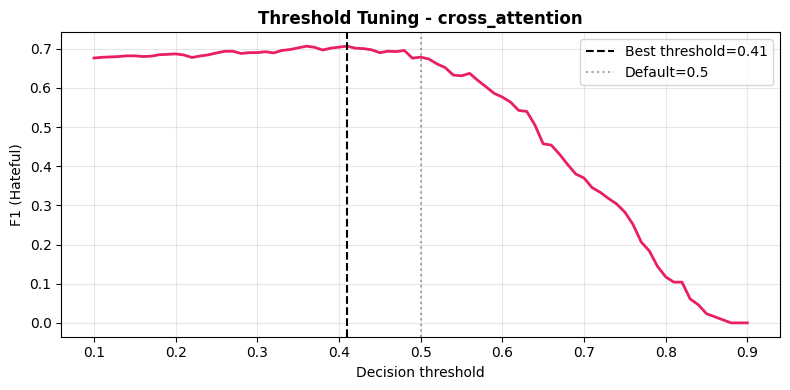

Default threshold (0.5) F1: 0.6788
Optimal threshold (0.41) F1: 0.7068


In [8]:
# -- Optimal threshold search (for best model) ------------------------
if not eval_results:
    print("SKIPPED: no checkpoints loaded, so threshold search was not generated.")
else:
    best_model_name = max(
        eval_results.keys(),
        key=lambda n: roc_auc_score(eval_results[n]["labels"], eval_results[n]["probs"]),
    )

    res = eval_results[best_model_name]
    labs = res["labels"]
    probs = res["probs"]

    thresholds = np.linspace(0.1, 0.9, 81)
    f1_scores = [f1_score(labs, (probs >= t).astype(int), pos_label=1) for t in thresholds]
    best_thresh = thresholds[np.argmax(f1_scores)]

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores, color="#E91E63", lw=2)
    plt.axvline(best_thresh, color="black", linestyle="--", label=f"Best threshold={best_thresh:.2f}")
    plt.axvline(0.5, color="gray", linestyle=":", alpha=0.7, label="Default=0.5")
    plt.xlabel("Decision threshold")
    plt.ylabel("F1 (Hateful)")
    plt.title(f"Threshold Tuning - {best_model_name}", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Default threshold (0.5) F1: {f1_score(labs, (probs >= 0.5).astype(int), pos_label=1):.4f}")
    print(f"Optimal threshold ({best_thresh:.2f}) F1: {max(f1_scores):.4f}")

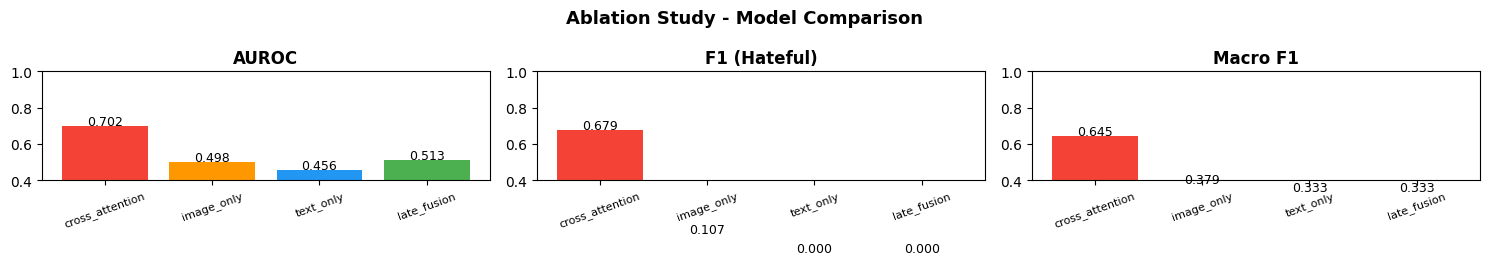

Evaluation notebook complete. Proceed to notebook 11 (Explainability).


In [ ]:
# -- Ablation bar chart -----------------------------------------------
if metrics_df.empty:
    print("SKIPPED: no metrics available, so ablation chart was not generated.")
else:
    colors = {
        "cross_attention": "#F44336",
        "cross_attention_phase2": "#E91E63",
        "cross_attention_vitl14": "#FF5722",
        "cross_attention_token_level": "#9C27B0",
        "image_only": "#FF9800",
        "text_only": "#2196F3",
        "late_fusion": "#4CAF50",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in [
        (axes[0], "AUROC", "AUROC"),
        (axes[1], "F1 (Hateful)", "F1 (Hateful)"),
        (axes[2], "Macro F1", "Macro F1"),
    ]:
        bars = ax.bar(
            metrics_df["Model"],
            metrics_df[col],
            color=[colors.get(m, "gray") for m in metrics_df["Model"]],
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center",
                fontsize=9,
            )
        ax.set_ylim(0.4, 1.0)
        ax.set_title(title, fontweight="bold")
        ax.tick_params(axis="x", labelrotation=20, labelsize=8)

    plt.suptitle("Ablation Study - Model Comparison", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ablation_chart.png"), dpi=150, bbox_inches="tight")
    plt.show()

print("Evaluation notebook complete. Proceed to notebook 11 (Explainability).")